# PatchTST + DLA Training (HF CSV, Kaggle-ready)

This notebook:
- Downloads `X_*` and `Y_*` CSVs from Hugging Face Hub.
- Builds `[N,T,F]` tensors from long-window X and aligned Y.
- Trains PatchTST + DLA model for binary wildfire prediction.
- Uses **2 GPUs automatically** when available (`DataParallel`).


In [1]:
!pip -q install huggingface_hub scikit-learn

In [2]:
from pathlib import Path
import os
import sys
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

MODEL_SRC = "/kaggle/input/models/nagrajgaonkar/wildfire/pytorch/default/1"
sys.path.append(MODEL_SRC)

from src.configs import DataConfig, ModelConfig, TrainConfig
from src.data_io import (
    download_hf_split_files,
    load_split_xy_csv,
    FeatureNormalizer,
    make_torch_datasets,
)
from src.model_patchtst_dla import PatchTSTDLAClassifier
from src.trainer import make_dataloaders, fit_model, evaluate_with_threshold_search
from src.utils import set_seed, device_summary

print("Using MODEL_SRC:", MODEL_SRC)

Using MODEL_SRC: /kaggle/input/models/nagrajgaonkar/wildfire/pytorch/default/1


In [3]:
best_params = {
    "d_model_n_heads": "160|10",
    "patch_len": 2,
    "n_layers": 6,
    "ff_mult": 2,
    "dropout": 0.2752613203374492,
    "mla_hidden": 192,
    "head_hidden": 128,
    "use_temporal_dla1d": True,
    "temporal_dla_base_channels": 32,
    "use_temporal_attention_pool": False,
    "use_window_embedding": True,
    "use_gated_fusion": True,
    "fusion_hidden": 192,
    "lr": 0.0012922555585796823,
    "weight_decay": 0.001466151770108544,
    "grad_clip_norm": 0.0,
    "patience": 5,
    "epochs": 19,
    "batch_size": 256,
}

In [4]:
d_model, n_heads = map(int, best_params["d_model_n_heads"].split("|"))

In [5]:
# -------------------------
# Config
# -------------------------
SEED = 42
set_seed(SEED, deterministic=True)

HF_X_REPO_ID = 'NagrajMG/WildFire-X'
HF_Y_REPO_ID = 'NagrajMG/WildFire-Y'

X_FILES = {
    'train': 'FEATURES_train.csv',
    'val': 'FEATURES_val.csv',
    'test': 'FEATURES_test.csv',
}
Y_FILES = {
    'train': 'LABELS_train.csv',
    'val': 'LABELS_val.csv',
    'test': 'LABELS_test.csv',
}

# Use Kaggle Secrets -> add HF_TOKEN if dataset is private
HF_TOKEN = os.getenv('HF_TOKEN', None)

WORK_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('/tmp')
ARTIFACT_DIR = WORK_DIR / 'Wildfire'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Must use 2 GPUs on Kaggle
REQUIRE_TWO_GPUS = True
USE_MULTI_GPU = True

gpu_info = device_summary()
print('GPU summary:', gpu_info)
if REQUIRE_TWO_GPUS and (not gpu_info['cuda_available'] or int(gpu_info['n_gpu']) < 2):
    raise RuntimeError(
        f"This notebook is configured for 2-GPU training. Found n_gpu={gpu_info['n_gpu']}. "
        "Enable 'GPU T4 x2' in Kaggle settings."
    )

# Data / model / train config
data_cfg = DataConfig(
    expected_windows=4,
    batch_size=best_params["batch_size"],
    num_workers=4,
    pin_memory=True,
    drop_last_train=False,
)

model_cfg = ModelConfig(
    seq_len=4,
    patch_len=best_params["patch_len"],
    patch_stride=1,
    d_model=d_model,
    n_heads=n_heads,
    n_layers=best_params["n_layers"],
    ff_mult=best_params["ff_mult"],
    dropout=best_params["dropout"],
    n_features=0,  # set after loading data

    mla_hidden=best_params["mla_hidden"],
    head_hidden=best_params["head_hidden"],

    use_temporal_dla1d=best_params["use_temporal_dla1d"],
    temporal_dla_base_channels=best_params["temporal_dla_base_channels"],
    use_temporal_attention_pool=best_params["use_temporal_attention_pool"],
    use_window_embedding=best_params["use_window_embedding"],
    use_summary_branches=True,
    use_gated_fusion=best_params["use_gated_fusion"],
    fusion_hidden=best_params["fusion_hidden"],
)

train_cfg = TrainConfig(
    epochs=best_params["epochs"],
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"],
    grad_clip_norm=best_params["grad_clip_norm"],
    patience=best_params["patience"],
    use_amp=True,
    loss_name="bce",
    pos_weight=1.0,
    monitor_metric="pr_auc",
    scheduler_name="cosine",
    min_lr=1e-5,
    threshold_grid_min=0.05,
    threshold_grid_max=0.95,
    threshold_grid_steps=19,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

GPU summary: {'cuda_available': True, 'n_gpu': 2, 'gpu_names': ['Tesla T4', 'Tesla T4']}
Device: cuda


In [6]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

In [7]:
# -------------------------
# Download split CSVs from HF
# -------------------------
paths = download_hf_split_files(
    x_repo_id=HF_X_REPO_ID,
    y_repo_id=HF_Y_REPO_ID,
    x_files=X_FILES,
    y_files=Y_FILES,
    token= user_secrets.get_secret("HUGGINGFACE_TOKEN"),
    repo_type='dataset',
    cache_dir=WORK_DIR / 'hf_cache',
)

print(json.dumps(paths, indent=2))


FEATURES_train.csv:   0%|          | 0.00/47.1M [00:00<?, ?B/s]

LABELS_train.csv: 0.00B [00:00, ?B/s]

FEATURES_val.csv:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

LABELS_val.csv: 0.00B [00:00, ?B/s]

FEATURES_test.csv: 0.00B [00:00, ?B/s]

LABELS_test.csv: 0.00B [00:00, ?B/s]

{
  "x_train": "/kaggle/working/hf_cache/datasets--NagrajMG--WildFire-X/snapshots/151325172729da2bd50e048108bf33ae55407a01/FEATURES_train.csv",
  "y_train": "/kaggle/working/hf_cache/datasets--NagrajMG--WildFire-Y/snapshots/5c10f82574a79f7dc8939387f7e39e1c275ba0dc/LABELS_train.csv",
  "x_val": "/kaggle/working/hf_cache/datasets--NagrajMG--WildFire-X/snapshots/151325172729da2bd50e048108bf33ae55407a01/FEATURES_val.csv",
  "y_val": "/kaggle/working/hf_cache/datasets--NagrajMG--WildFire-Y/snapshots/5c10f82574a79f7dc8939387f7e39e1c275ba0dc/LABELS_val.csv",
  "x_test": "/kaggle/working/hf_cache/datasets--NagrajMG--WildFire-X/snapshots/151325172729da2bd50e048108bf33ae55407a01/FEATURES_test.csv",
  "y_test": "/kaggle/working/hf_cache/datasets--NagrajMG--WildFire-Y/snapshots/5c10f82574a79f7dc8939387f7e39e1c275ba0dc/LABELS_test.csv"
}


In [8]:
# -------------------------
# Load arrays and align X/Y
# -------------------------
train_arr = load_split_xy_csv(paths['x_train'], paths['y_train'], split_name='train', expected_windows=data_cfg.expected_windows)
val_arr = load_split_xy_csv(paths['x_val'], paths['y_val'], split_name='val', expected_windows=data_cfg.expected_windows)
test_arr = load_split_xy_csv(paths['x_test'], paths['y_test'], split_name='test', expected_windows=data_cfg.expected_windows)

print('train x:', train_arr.x.shape, 'y:', train_arr.y.shape)
print('val   x:', val_arr.x.shape, 'y:', val_arr.y.shape)
print('test  x:', test_arr.x.shape, 'y:', test_arr.y.shape)
print('n_features:', len(train_arr.feature_cols))


train x: (47530, 4, 25) y: (47530,)
val   x: (10290, 4, 25) y: (10290,)
test  x: (1890, 4, 25) y: (1890,)
n_features: 25


In [9]:
# -------------------------
# Normalize with train-only stats
# -------------------------
normalizer = FeatureNormalizer()
train_arr.x = normalizer.fit_transform(train_arr.x)
val_arr.x = normalizer.transform(val_arr.x)
test_arr.x = normalizer.transform(test_arr.x)

# Optional class-balance pos_weight
pos = float((train_arr.y == 1).sum())
neg = float((train_arr.y == 0).sum())
if pos > 0:
    train_cfg.pos_weight = max(1.0, neg / pos)
print('pos_weight:', train_cfg.pos_weight)


pos_weight: 1.0


In [10]:
# -------------------------
# Torch datasets/loaders
# -------------------------
train_ds, val_ds, test_ds = make_torch_datasets(train_arr, val_arr, test_arr)
train_loader, val_loader, test_loader = make_dataloaders(train_ds, val_ds, test_ds, data_cfg)

batch0 = next(iter(train_loader))
print('batch x:', tuple(batch0['x'].shape))  # [B,T,F]
print('batch y:', tuple(batch0['y'].shape))  # [B]


batch x: (256, 4, 25)
batch y: (256,)


In [11]:
# -------------------------
# Build model (PatchTST + DLA)
# -------------------------
model_cfg.n_features = int(train_arr.x.shape[2])
model = PatchTSTDLAClassifier(model_cfg)
print(model)

PatchTSTDLAClassifier(
  (tokenizer): PatchTokenizer(
    (proj): Linear(in_features=2, out_features=160, bias=True)
    (drop): Dropout(p=0.2752613203374492, inplace=False)
  )
  (encoder): TransformerPatchEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=160, out_features=160, bias=True)
        )
        (linear1): Linear(in_features=160, out_features=320, bias=True)
        (dropout): Dropout(p=0.2752613203374492, inplace=False)
        (linear2): Linear(in_features=320, out_features=160, bias=True)
        (norm1): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2752613203374492, inplace=False)
        (dropout2): Dropout(p=0.2752613203374492, inplace=False)
      )
    )
  )
  (dla): DLAAggregator(
    (fusions): ModuleList(
      (0-3): 4 x

In [12]:
# -------------------------
# Train (uses 2 GPUs if available)
# -------------------------
train_out = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    cfg=train_cfg,
    device=device,
    use_multi_gpu=USE_MULTI_GPU,
)

trained_model = train_out['model']
history = pd.DataFrame(train_out['history'])
print('Best val loss:', train_out['best_val_loss'])
print('Best monitor metric:', train_out['best_monitor_metric'], 'value:', train_out['best_monitor_value'])
print('GPUs used (requested multi-gpu):', train_out['n_gpu_used'])

if REQUIRE_TWO_GPUS and int(train_out['n_gpu_used']) < 2:
    raise RuntimeError(f"Expected 2 GPUs but training used {train_out['n_gpu_used']}")

history.tail()



/kaggle/input/models/nagrajgaonkar/wildfire/pytorch/default/1/src/trainer.py:204: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=bool(cfg.use_amp and device.type == "cuda"))
/kaggle/input/models/nagrajgaonkar/wildfire/pytorch/default/1/src/trainer.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):
/kaggle/input/models/nagrajgaonkar/wildfire/pytorch/default/1/src/trainer.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):
/kaggle/input/models/nagrajgaonkar/wildfire/pytorch/default/1/src/trainer.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda',

Best val loss: 0.5579341631125663
Best monitor metric: pr_auc value: 0.8117686596596485
GPUs used (requested multi-gpu): 2


,epoch,train_loss,val_loss,val_pr_auc,val_precision,val_recall,val_f1,val_iou,val_specificity,lr
8,9.0,0.458110,0.610427,0.786778,0.710353,0.692128,0.701122,0.539791,0.717784,0.000809
9,10.0,0.450612,0.579751,0.806498,0.743584,0.681438,0.711156,0.551778,0.765015,0.000704
10,11.0,0.443761,0.571900,0.810018,0.737395,0.696404,0.716313,0.558013,0.751992,0.000598
11,12.0,0.436247,0.584567,0.811502,0.745981,0.685520,0.714474,0.555783,0.766569,0.000494
12,13.0,0.429635,0.643432,0.782948,0.743779,0.586783,0.656019,0.488116,0.797862,0.000394


In [13]:
def print_metrics(title, m):
    print(f"\n{title}")
    print("-" * len(title))
    print(f"Threshold     : {m.get('threshold', 'N/A'):.4f}")
    print(f"PR AUC        : {m['pr_auc']:.4f}")
    print(f"Precision     : {m['precision']:.4f}")
    print(f"Recall        : {m['recall']:.4f}")
    print(f"F1 Score      : {m['f1']:.4f}")
    print(f"IoU           : {m['iou']:.4f}")
    print(f"Specificity   : {m['specificity']:.4f}")
    print(f"TP / FP / FN / TN : {m['tp']} / {m['fp']} / {m['fn']} / {m['tn']}")

In [14]:
# -------------------------
# Evaluate + threshold tuning
# -------------------------
eval_out = evaluate_with_threshold_search(
    model=trained_model,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    cfg=train_cfg,
)

print('best threshold:', eval_out['best_threshold_from_val'])
print('val @ best:', eval_out['val_metrics_at_best_threshold'])
print('test @ best:', eval_out['test_metrics_at_best_threshold'])
print('test @ 0.5:', eval_out['test_metrics_at_0_5'])


best threshold: 0.3
val @ best: {'threshold': 0.3, 'pr_auc': 0.8117686596596485, 'precision': 0.6708153821605234, 'recall': 0.8171039844509232, 'f1': 0.7367683140553803, 'iou': 0.5832408435072142, 'specificity': 0.599028182701652, 'tp': 4204, 'fp': 2063, 'fn': 941, 'tn': 3082}
test @ best: {'threshold': 0.3, 'pr_auc': 0.8349767405862903, 'precision': 0.6893382352941176, 'recall': 0.7936507936507936, 'f1': 0.7378258730939499, 'iou': 0.5845674201091192, 'specificity': 0.6423280423280423, 'tp': 750, 'fp': 338, 'fn': 195, 'tn': 607}
test @ 0.5: {'threshold': 0.5, 'pr_auc': 0.8349767405862903, 'precision': 0.8140703517587939, 'recall': 0.6857142857142857, 'f1': 0.7443997702469844, 'iou': 0.5928636779505947, 'specificity': 0.8433862433862434, 'tp': 648, 'fp': 148, 'fn': 297, 'tn': 797}


In [15]:
print("\n================ EVALUATION SUMMARY ================\n")

best_thr = eval_out['best_threshold_from_val']
print(f"Best Threshold (from validation): {best_thr:.4f}")

print_metrics("Validation @ Best Threshold", eval_out['val_metrics_at_best_threshold'])
print_metrics("Test @ Best Threshold", eval_out['test_metrics_at_best_threshold'])
print_metrics("Test @ 0.5 Threshold", eval_out['test_metrics_at_0_5'])

print("\n===================================================\n")


================ EVALUATION SUMMARY ================

Best Threshold (from validation): 0.3000

Validation @ Best Threshold
---------------------------
Threshold     : 0.3000
PR AUC        : 0.8118
Precision     : 0.6708
Recall        : 0.8171
F1 Score      : 0.7368
IoU           : 0.5832
Specificity   : 0.5990
TP / FP / FN / TN : 4204 / 2063 / 941 / 3082

Test @ Best Threshold
---------------------
Threshold     : 0.3000
PR AUC        : 0.8350
Precision     : 0.6893
Recall        : 0.7937
F1 Score      : 0.7378
IoU           : 0.5846
Specificity   : 0.6423
TP / FP / FN / TN : 750 / 338 / 195 / 607

Test @ 0.5 Threshold
--------------------
Threshold     : 0.5000
PR AUC        : 0.8350
Precision     : 0.8141
Recall        : 0.6857
F1 Score      : 0.7444
IoU           : 0.5929
Specificity   : 0.8434
TP / FP / FN / TN : 648 / 148 / 297 / 797




In [16]:
from sklearn.metrics import confusion_matrix

# -------------------------
# Confusion Matrix (Test set)
# -------------------------
y_true = eval_out["test_y_true"]
y_prob = eval_out["test_y_prob"]

# 1) Using best threshold
best_thr = eval_out["best_threshold_from_val"]
y_pred_best = (y_prob >= best_thr).astype(int)

cm_best = confusion_matrix(y_true, y_pred_best)
print("Confusion Matrix (Test @ best threshold):")
print(cm_best)

# 2) Using 0.5 threshold
y_pred_05 = (y_prob >= 0.5).astype(int)

cm_05 = confusion_matrix(y_true, y_pred_05)
print("\nConfusion Matrix (Test @ 0.5):")
print(cm_05)

Confusion Matrix (Test @ best threshold):
[[607 338]
 [195 750]]

Confusion Matrix (Test @ 0.5):
[[797 148]
 [297 648]]


In [17]:
# -------------------------
# Save checkpoint + report
# -------------------------
base_model = trained_model.module if isinstance(trained_model, torch.nn.DataParallel) else trained_model
ckpt_path = ARTIFACT_DIR / 'patchtst_dla_best.pt'
torch.save(
    {
        'model_state_dict': base_model.state_dict(),
        'model_config': model_cfg.__dict__,
        'feature_cols': train_arr.feature_cols,
        'normalizer': normalizer.to_dict(),
        'train_config': train_cfg.__dict__,
    },
    ckpt_path,
)

report = {
    'best_val_loss': float(train_out['best_val_loss']),
    'device': str(device),
    'gpu_summary': device_summary(),
    'n_gpu_used': int(train_out['n_gpu_used']),
    'best_threshold': float(eval_out['best_threshold_from_val']),
    'val_metrics_best_threshold': eval_out['val_metrics_at_best_threshold'],
    'test_metrics_best_threshold': eval_out['test_metrics_at_best_threshold'],
    'test_metrics_0_5': eval_out['test_metrics_at_0_5'],
    'feature_count': int(len(train_arr.feature_cols)),
    'train_rows': int(len(train_arr.y)),
    'val_rows': int(len(val_arr.y)),
    'test_rows': int(len(test_arr.y)),
}
report_path = ARTIFACT_DIR / 'metrics_report.json'
report_path.write_text(json.dumps(report, indent=2), encoding='utf-8')

print('Saved checkpoint:', ckpt_path)
print('Saved report    :', report_path)


Saved checkpoint: /kaggle/working/Wildfire/patchtst_dla_best.pt
Saved report    : /kaggle/working/Wildfire/metrics_report.json


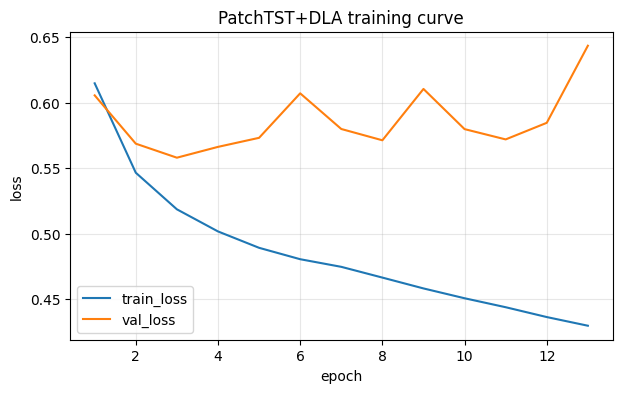

In [18]:
# -------------------------
# Training curve
# -------------------------
if len(history) > 0:
    plt.figure(figsize=(7,4))
    plt.plot(history['epoch'], history['train_loss'], label='train_loss')
    plt.plot(history['epoch'], history['val_loss'], label='val_loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('PatchTST+DLA training curve')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


## Model Explainability with SHAP

This section adds practical SHAP analysis for the trained binary logit model.
- Explains **raw logits** by default (not thresholded predictions)
- Uses `GradientExplainer` first, then `DeepExplainer` fallback
- Optional `KernelExplainer` fallback only if both gradient-based methods fail
- Produces global + local views and saves artifacts


In [19]:
# -------------------------
# SHAP imports (guarded)
# -------------------------
try:
    import shap
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path

sns.set_theme(style="whitegrid")


In [20]:
# -------------------------
# SHAP config + helper functions
# -------------------------
SHAP_RANDOM_SEED = 42
SHAP_BACKGROUND_SIZE = 64
SHAP_EXPLAIN_SIZE = 128
SHAP_MAX_DISPLAY = 30
SHAP_ENABLE_KERNEL_FALLBACK = True

explain_dir = Path("/kaggle/working/artifacts") / "shap"
explain_dir.mkdir(parents=True, exist_ok=True)

class ModelLogitWrapper(torch.nn.Module):
    """Wrap model to return [B,1] raw logits for SHAP."""
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        logits = self.model(x)
        return logits.unsqueeze(-1)

def normalize_shap_output(shap_values, x_shape):
    """Normalize SHAP output to ndarray shape [N,T,F]."""
    n, t, f = x_shape

    sv = shap_values
    if isinstance(sv, list):
        if len(sv) == 0:
            raise ValueError("Empty SHAP list output")
        sv = sv[0]

    if torch.is_tensor(sv):
        sv = sv.detach().cpu().numpy()
    else:
        sv = np.asarray(sv)

    # Common SHAP output variants
    if sv.ndim == 4 and sv.shape[0] == 1:      # [1,N,T,F]
        sv = sv[0]
    if sv.ndim == 4 and sv.shape[-1] == 1:     # [N,T,F,1]
        sv = sv[..., 0]
    if sv.ndim == 4 and sv.shape[1] == 1:      # [N,1,T,F]
        sv = sv[:, 0, :, :]
    if sv.ndim == 2 and sv.shape[1] == t * f:  # [N,T*F]
        sv = sv.reshape(n, t, f)
    if sv.ndim == 3 and sv.shape[0] == 1 and sv.shape[1] == n and sv.shape[2] == t * f:
        sv = sv[0].reshape(n, t, f)

    if sv.shape != (n, t, f):
        raise ValueError(f"Unexpected SHAP shape {sv.shape}; expected {(n,t,f)}")
    return sv.astype(np.float32)

def _safe_prob_from_logit(logits):
    return 1.0 / (1.0 + np.exp(-np.clip(logits, -30, 30)))

def _build_flat_feature_names(base_feature_names, t_steps):
    return [f"w{w}:{feat}" for w in range(1, t_steps + 1) for feat in base_feature_names]


In [21]:
# -------------------------
# Prepare subsets + wrapper model (logit explanation)
# -------------------------
if "trained_model" not in globals():
    raise RuntimeError("trained_model not found. Run training or checkpoint-loading cells first.")

base_model = trained_model.module if isinstance(trained_model, torch.nn.DataParallel) else trained_model
base_model.eval()
wrapper_model = ModelLogitWrapper(base_model).to(device).eval()

# Prefer validation split for explainability; fallback to test
if "val_arr" in globals() and hasattr(val_arr, "x") and len(val_arr.x) > 0:
    explain_arr = val_arr
    explain_split_name = "val"
else:
    explain_arr = test_arr
    explain_split_name = "test"

rng = np.random.default_rng(SHAP_RANDOM_SEED)

bg_n = min(SHAP_BACKGROUND_SIZE, len(train_arr.x))
ex_n = min(SHAP_EXPLAIN_SIZE, len(explain_arr.x))

bg_idx = rng.choice(len(train_arr.x), size=bg_n, replace=False)
ex_idx = rng.choice(len(explain_arr.x), size=ex_n, replace=False)

x_background_np = train_arr.x[bg_idx].astype(np.float32)
x_explain_np = explain_arr.x[ex_idx].astype(np.float32)
y_explain_np = explain_arr.y[ex_idx].astype(np.int64)
keys_explain_df = explain_arr.keys.iloc[ex_idx].reset_index(drop=True).copy()

x_background_tensor = torch.as_tensor(x_background_np, dtype=torch.float32, device=device)
x_explain_tensor = torch.as_tensor(x_explain_np, dtype=torch.float32, device=device)

T = int(x_explain_np.shape[1])
F = int(x_explain_np.shape[2])
base_feature_names = list(train_arr.feature_cols)
window_labels = [f"w{i}" for i in range(1, T + 1)]
flat_feature_names = _build_flat_feature_names(base_feature_names, T)

assert len(flat_feature_names) == T * F, "flat feature name count mismatch"

print("Explain split:", explain_split_name)
print("Background tensor:", tuple(x_background_tensor.shape))
print("Explain tensor:", tuple(x_explain_tensor.shape))


Explain split: val
Background tensor: (64, 4, 25)
Explain tensor: (128, 4, 25)


In [22]:
# -------------------------
# SHAP explainer logic (Gradient -> Deep -> optional Kernel)
# -------------------------
explainer_name = None
explainer_errors = {}

try:
    explainer = shap.GradientExplainer(wrapper_model, x_background_tensor)
    shap_values_raw = explainer.shap_values(x_explain_tensor)
    explainer_name = "GradientExplainer"
except Exception as e_grad:
    explainer_errors["GradientExplainer"] = str(e_grad)
    try:
        explainer = shap.DeepExplainer(wrapper_model, x_background_tensor)
        shap_values_raw = explainer.shap_values(x_explain_tensor)
        explainer_name = "DeepExplainer"
    except Exception as e_deep:
        explainer_errors["DeepExplainer"] = str(e_deep)
        if not SHAP_ENABLE_KERNEL_FALLBACK:
            raise RuntimeError(f"SHAP explanation failed: {explainer_errors}")

        # Slow fallback only when both gradient-based explainers fail.
        print("WARNING: Falling back to KernelExplainer (slow).")
        k_bg_n = min(32, x_background_np.shape[0])
        k_ex_n = min(64, x_explain_np.shape[0])

        x_bg_k = x_background_np[:k_bg_n].reshape(k_bg_n, -1)
        x_ex_k = x_explain_np[:k_ex_n]
        y_explain_np = y_explain_np[:k_ex_n]
        keys_explain_df = keys_explain_df.iloc[:k_ex_n].reset_index(drop=True)

        def _kernel_predict(x_flat):
            x_in = torch.as_tensor(x_flat.reshape(-1, T, F), dtype=torch.float32, device=device)
            with torch.no_grad():
                out = wrapper_model(x_in).detach().cpu().numpy()
            return out

        explainer = shap.KernelExplainer(_kernel_predict, x_bg_k)
        shap_values_raw = explainer.shap_values(x_ex_k.reshape(k_ex_n, -1), nsamples=200)
        x_explain_np = x_ex_k
        x_explain_tensor = torch.as_tensor(x_explain_np, dtype=torch.float32, device=device)
        explainer_name = "KernelExplainer"

shap_values_np = normalize_shap_output(shap_values_raw, x_explain_np.shape)
assert shap_values_np.shape == x_explain_np.shape

# Prediction table for the explained subset
with torch.no_grad():
    logits_explain = base_model(x_explain_tensor).detach().cpu().numpy().reshape(-1)
    bg_logit_mean = float(base_model(x_background_tensor).detach().cpu().numpy().reshape(-1).mean())

probs_explain = _safe_prob_from_logit(logits_explain)
pred_explain = (probs_explain >= 0.5).astype(np.int64)

pred_df = keys_explain_df.copy()
pred_df["sample_idx"] = np.arange(len(pred_df), dtype=np.int64)
pred_df["y_true"] = y_explain_np.astype(np.int64)
pred_df["logit"] = logits_explain.astype(float)
pred_df["prob"] = probs_explain.astype(float)
pred_df["pred_0_5"] = pred_explain.astype(np.int64)

print("Explainer used:", explainer_name)
if explainer_errors:
    print("Fallback details:", explainer_errors)
print("SHAP shape:", shap_values_np.shape)


Explainer used: GradientExplainer
SHAP shape: (128, 4, 25)


In [23]:
# -------------------------
# Global importance tables
# -------------------------
abs_shap = np.abs(shap_values_np)

# A) per (window, feature)
mean_abs_wf = abs_shap.mean(axis=0)  # [T,F]
rows = []
for wi in range(T):
    for fi in range(F):
        rows.append({
            "window": f"w{wi+1}",
            "feature": base_feature_names[fi],
            "mean_abs_shap": float(mean_abs_wf[wi, fi]),
        })
wf_df = pd.DataFrame(rows).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

# B) feature-wise aggregated over windows
feature_imp = abs_shap.mean(axis=(0, 1))  # [F]
feature_df = pd.DataFrame({
    "feature": base_feature_names,
    "mean_abs_shap": feature_imp.astype(float),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

# C) window-wise aggregated over features
window_imp = abs_shap.mean(axis=(0, 2))  # [T]
window_df = pd.DataFrame({
    "window": [f"w{i+1}" for i in range(T)],
    "mean_abs_shap": window_imp.astype(float),
})

display(wf_df.head(30))
display(feature_df.head(20))
display(window_df)

wf_df.to_csv(explain_dir / "shap_window_feature_importance.csv", index=False)
feature_df.to_csv(explain_dir / "shap_feature_importance.csv", index=False)
window_df.to_csv(explain_dir / "shap_window_importance.csv", index=False)


,window,feature,mean_abs_shap
0,w1,ignition_prob_clim,0.524200
1,w3,slope,0.259885
2,w1,vpd,0.255943
3,w3,vpd,0.247657
4,w2,slope,0.246956
5,w1,isi,0.215494
6,w3,elevation,0.205611
7,w3,fm100,0.202559
8,w1,solar_rad,0.197026
9,w2,ignition_prob_clim,0.183479


,feature,mean_abs_shap
0,ignition_prob_clim,0.260197
1,slope,0.210057
2,vpd,0.186745
3,elevation,0.143534
4,aet,0.128811
5,solar_rad,0.125674
6,aspect_cos,0.120167
7,isi,0.109628
8,fm100,0.104498
9,dc,0.103590


,window,mean_abs_shap
0,w1,0.105264
1,w2,0.084581
2,w3,0.117199
3,w4,0.081549


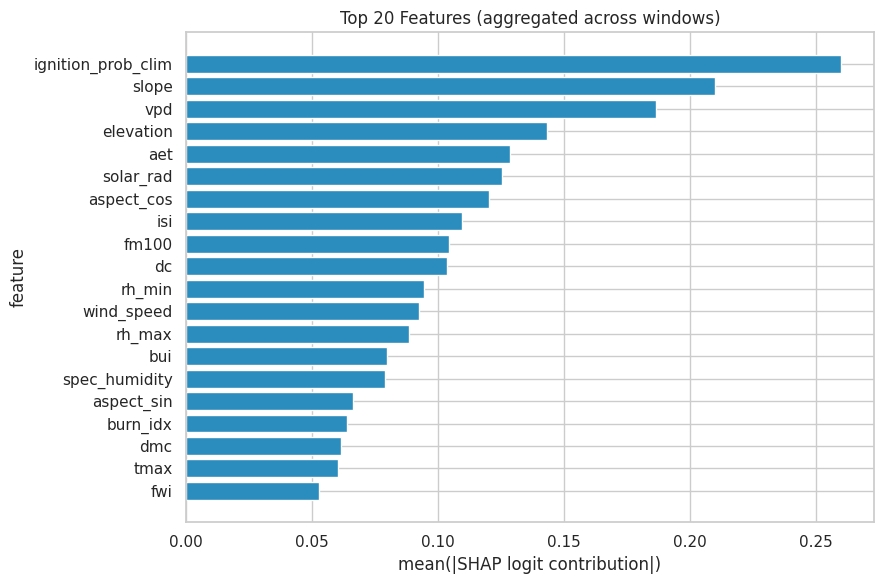

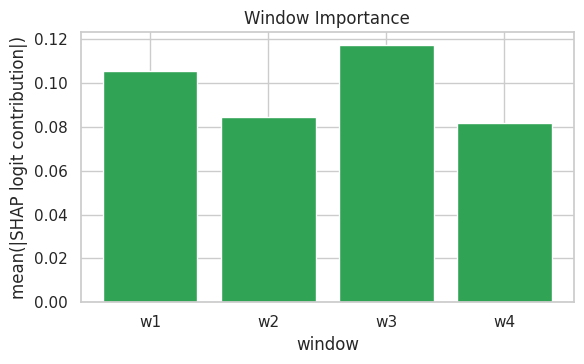

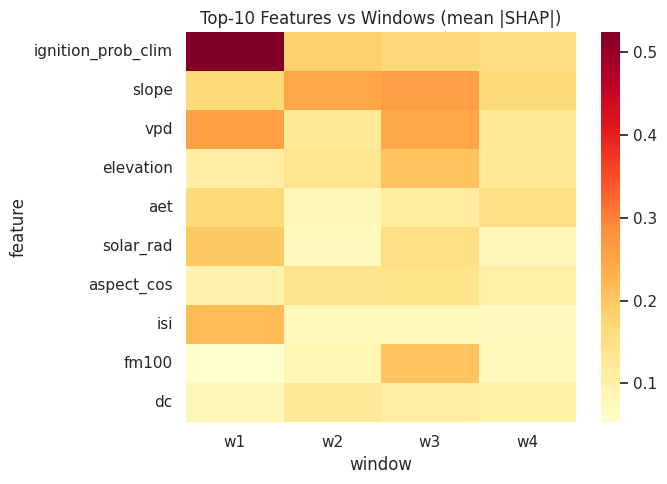

/tmp/ipykernel_55/3943594434.py:48: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(flat_shap, flat_x, feature_names=flat_feature_names, max_display=SHAP_MAX_DISPLAY, show=False)


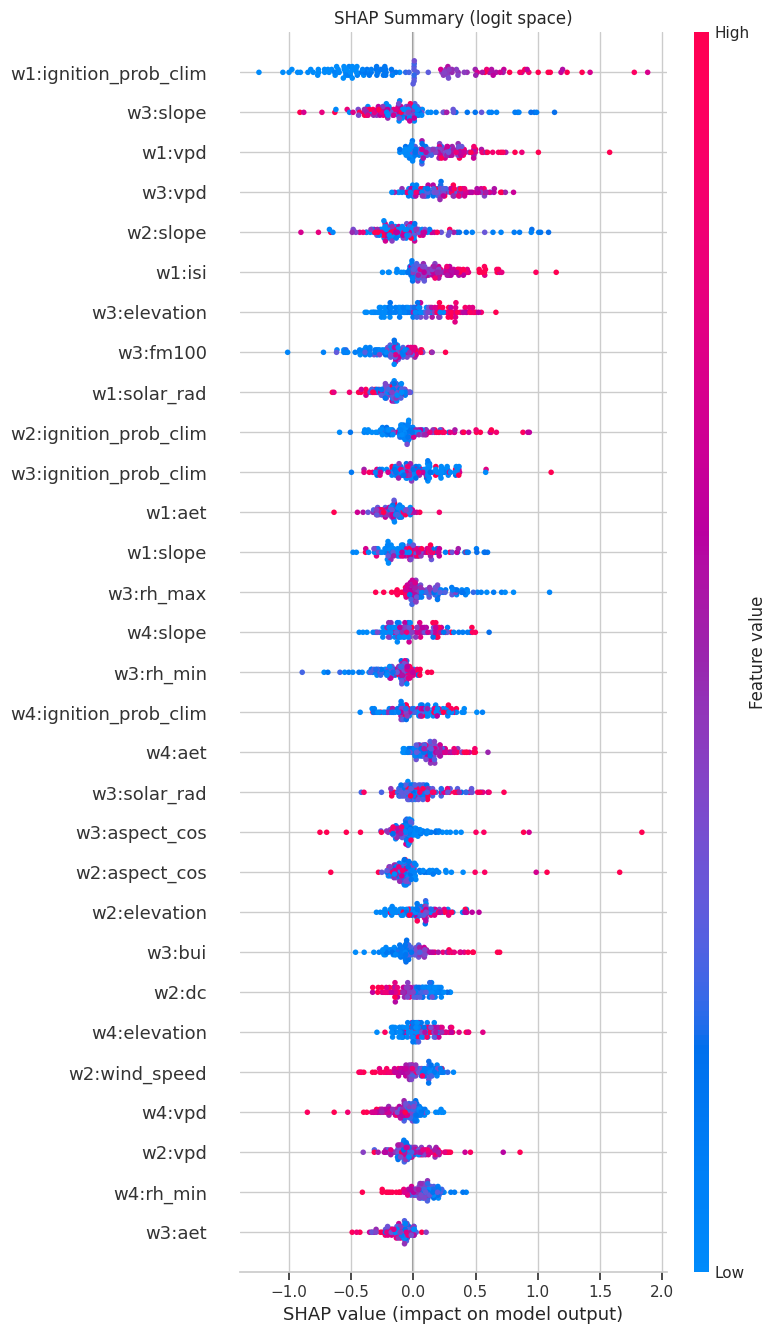

In [24]:
# -------------------------
# Global plots + summary plot (saved PNGs)
# -------------------------
# 1) Feature bar (top 20)
top20 = feature_df.head(20).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top20["feature"], top20["mean_abs_shap"], color="#2b8cbe")
plt.xlabel("mean(|SHAP logit contribution|)")
plt.ylabel("feature")
plt.title("Top 20 Features (aggregated across windows)")
plt.tight_layout()
plt.savefig(explain_dir / "shap_feature_bar.png", dpi=180)
plt.show()

# 2) Window bar
plt.figure(figsize=(6, 3.8))
plt.bar(window_df["window"], window_df["mean_abs_shap"], color="#31a354")
plt.xlabel("window")
plt.ylabel("mean(|SHAP logit contribution|)")
plt.title("Window Importance")
plt.tight_layout()
plt.savefig(explain_dir / "shap_window_bar.png", dpi=180)
plt.show()

# 3) Top-10 feature x window heatmap
top10_features = feature_df.head(10)["feature"].tolist()
top10_idx = [base_feature_names.index(f) for f in top10_features]
heat = mean_abs_wf[:, top10_idx].T  # [10,T]
heat_df = pd.DataFrame(heat, index=top10_features, columns=[f"w{i+1}" for i in range(T)])

plt.figure(figsize=(7, 5))
sns.heatmap(heat_df, cmap="YlOrRd", annot=False)
plt.title("Top-10 Features vs Windows (mean |SHAP|)")
plt.xlabel("window")
plt.ylabel("feature")
plt.tight_layout()
plt.savefig(explain_dir / "shap_top_feature_window_heatmap.png", dpi=180)
plt.show()

# Flattened summary plot
flat_x = x_explain_np.reshape(x_explain_np.shape[0], -1)
flat_shap = shap_values_np.reshape(shap_values_np.shape[0], -1)

assert flat_x.shape[1] == len(flat_feature_names), "Flat name mismatch"
assert flat_shap.shape == flat_x.shape, "Flattened SHAP mismatch"

plt.figure(figsize=(11, 6))
shap.summary_plot(flat_shap, flat_x, feature_names=flat_feature_names, max_display=SHAP_MAX_DISPLAY, show=False)
plt.title("SHAP Summary (logit space)")
plt.tight_layout()
plt.savefig(explain_dir / "shap_summary.png", dpi=180)
plt.show()



 ============ TP ============
{'target_date': '2021-08-01', 'row': 59, 'col': 63, 'y_true': 1, 'logit': 1.3644157648086548, 'prob': 0.7964764833450317, 'pred_0_5': 1}
Top positive contributors:


,window,feature,shap_value,feature_value
0,w3,solar_rad,0.609200,2.047446
1,w3,vpd,0.512202,1.418727
2,w3,elevation,0.470902,1.921063
3,w3,rh_max,0.388284,-0.914175
4,w2,fm100,0.318599,-1.631481
5,w4,elevation,0.308179,1.921063
6,w2,elevation,0.288147,1.921063
7,w3,tmax,0.271530,2.106830
8,w4,fm100,0.261719,-1.202954
9,w3,ignition_prob_clim,0.242931,-0.975661


Top negative contributors:


,window,feature,shap_value,feature_value
0,w1,ignition_prob_clim,-0.711870,-0.975661
1,w1,rh_max,-0.403293,-2.689193
2,w2,rh_max,-0.348321,-2.307040
3,w3,ffmc,-0.289022,1.750734
4,w3,tmin,-0.270335,2.212227
5,w1,aet,-0.253898,1.011237
6,w3,fm100,-0.206080,-0.899060
7,w3,wind_speed,-0.186725,0.606889
8,w2,solar_rad,-0.169907,0.988046
9,w4,solar_rad,-0.167118,1.018588


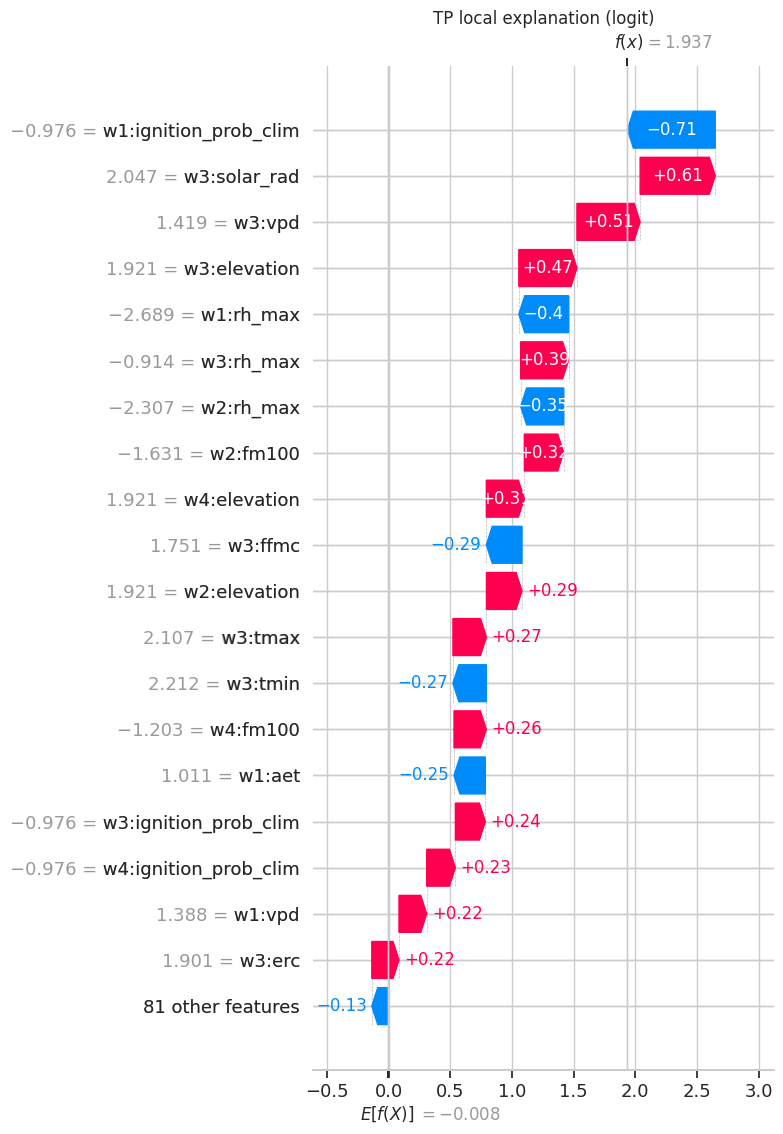


 ============ FP ============
{'target_date': '2019-08-11', 'row': 55, 'col': 69, 'y_true': 0, 'logit': 2.4200658798217773, 'prob': 0.9183447360992432, 'pred_0_5': 1}
Top positive contributors:


,window,feature,shap_value,feature_value
0,w3,solar_rad,0.728658,2.177604
1,w4,elevation,0.558863,1.540312
2,w4,slope,0.498602,1.966386
3,w3,elevation,0.476225,1.540312
4,w1,slope,0.424860,1.966386
5,w4,rh_min,0.301865,-0.926189
6,w4,aet,0.299499,1.076960
7,w2,slope,0.292700,1.966386
8,w4,ignition_prob_clim,0.277204,-0.975661
9,w2,elevation,0.248696,1.540312


Top negative contributors:


,window,feature,shap_value,feature_value
0,w1,aet,-0.254066,0.983564
1,w1,rh_max,-0.247481,-1.235842
2,w1,solar_rad,-0.215649,0.851317
3,w3,bui,-0.199690,-0.684274
4,w1,fm100,-0.197638,-1.261293
5,w3,tmin,-0.191400,1.978201
6,w3,ffmc,-0.187920,1.945588
7,w3,aet,-0.185169,1.419409
8,w1,rh_min,-0.183822,-0.964074
9,w4,isi,-0.148862,0.807568


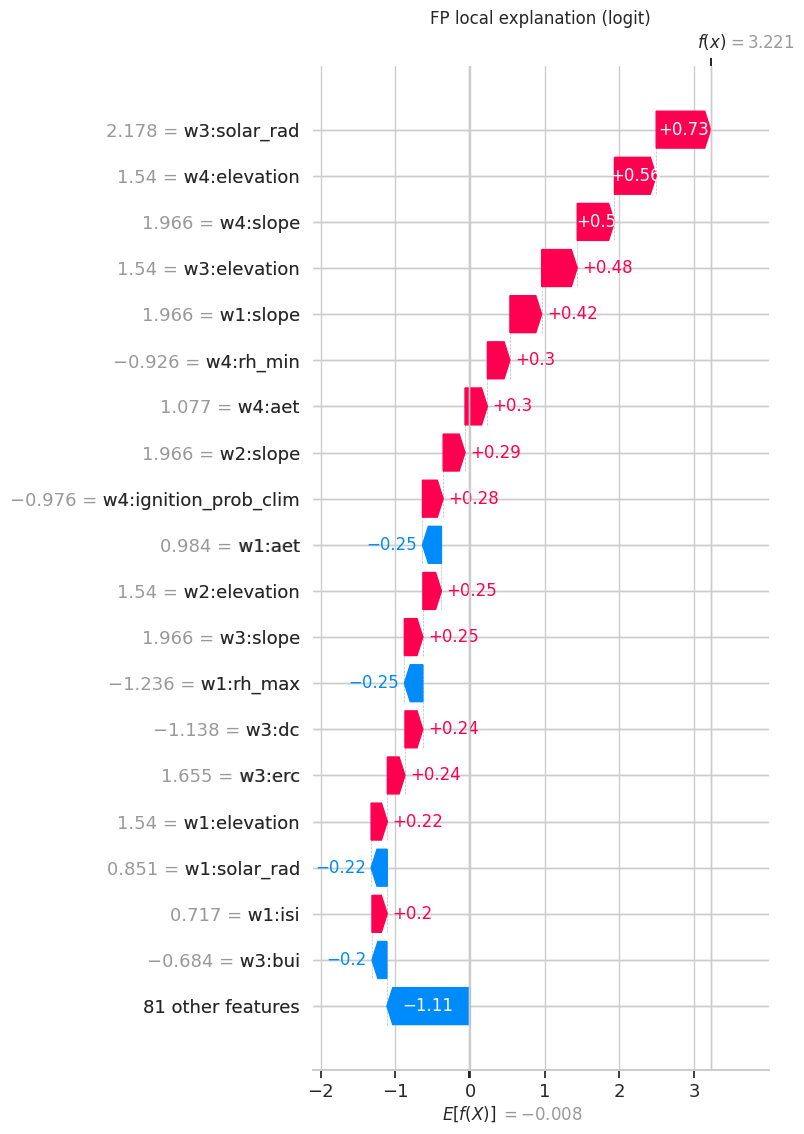


 ============ FN ============
{'target_date': '2018-08-18', 'row': 35, 'col': 37, 'y_true': 1, 'logit': -0.7978553175926208, 'prob': 0.31048446893692017, 'pred_0_5': 0}
Top positive contributors:


,window,feature,shap_value,feature_value
0,w3,vpd,0.613080,1.774175
1,w3,rh_max,0.403664,-1.302739
2,w4,aet,0.311222,1.388277
3,w1,isi,0.287316,1.265782
4,w2,fm100,0.233096,-1.649513
5,w3,ignition_prob_clim,0.226909,-0.975661
6,w1,vpd,0.214006,2.329259
7,w3,isi,0.141076,0.747264
8,w4,rh_min,0.138878,-1.006170
9,w4,elevation,0.108711,-0.082449


Top negative contributors:


,window,feature,shap_value,feature_value
0,w1,ignition_prob_clim,-0.656150,-0.975661
1,w3,slope,-0.531228,1.561959
2,w4,vpd,-0.526872,1.903555
3,w2,slope,-0.403464,1.561959
4,w3,fm100,-0.397093,-1.433128
5,w2,vpd,-0.313291,3.230748
6,w1,aet,-0.294478,1.367523
7,w1,solar_rad,-0.256727,0.875603
8,w3,rh_min,-0.216876,-0.972494
9,w2,rh_max,-0.197298,-2.361394


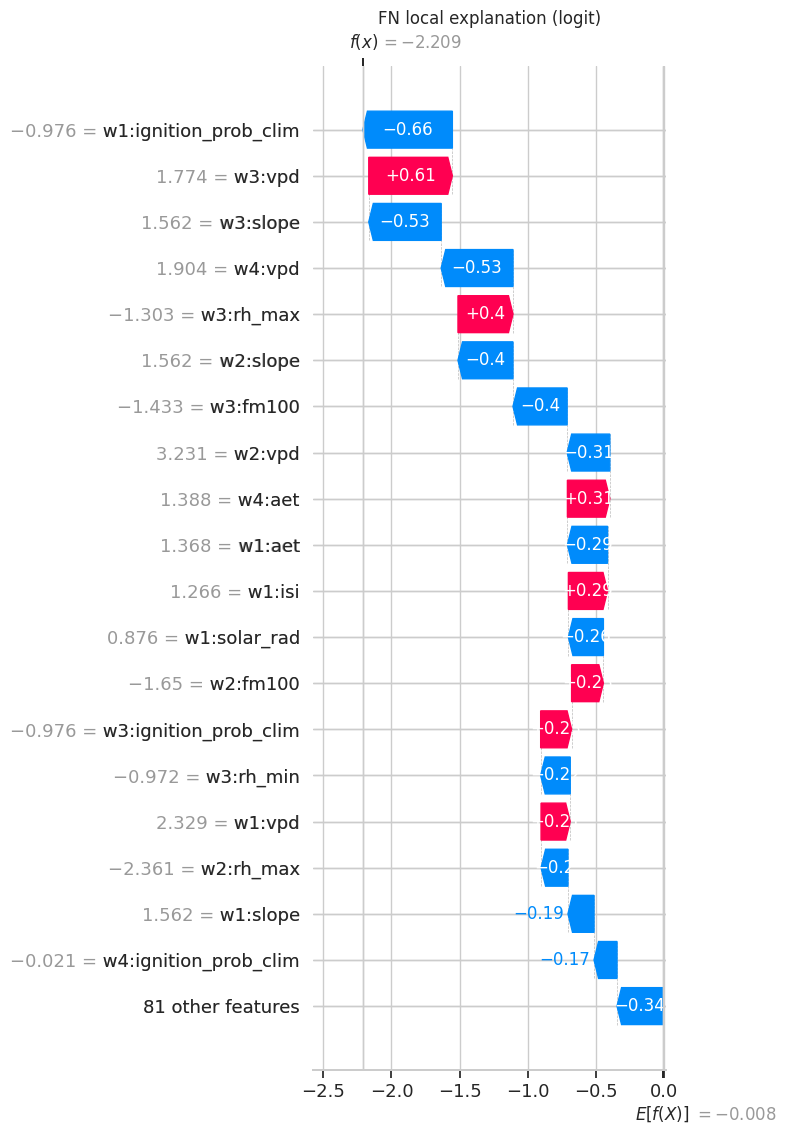


 ============ TN ============
{'target_date': '2021-08-02', 'row': 40, 'col': 37, 'y_true': 0, 'logit': -0.2559683322906494, 'prob': 0.4363550543785095, 'pred_0_5': 0}
Top positive contributors:


,window,feature,shap_value,feature_value
0,w3,vpd,0.575022,3.093020
1,w1,vpd,0.463264,3.205707
2,w4,aet,0.256463,2.332608
3,w4,pdsi,0.243818,-2.608271
4,w3,rh_max,0.195619,-1.535209
5,w2,vpd,0.187665,2.884342
6,w1,isi,0.157764,1.273258
7,w2,pdsi,0.135397,-1.248687
8,w3,wind_speed,0.130006,-1.329463
9,w4,rh_min,0.087543,-0.427362


Top negative contributors:


,window,feature,shap_value,feature_value
0,w4,vpd,-0.268753,2.512895
1,w3,fm100,-0.229451,-1.534956
2,w1,slope,-0.227910,-0.570438
3,w4,ignition_prob_clim,-0.226872,-0.931434
4,w3,rh_min,-0.174948,-1.241902
5,w2,slope,-0.171381,-0.570438
6,w4,isi,-0.150174,1.544578
7,w1,solar_rad,-0.145982,0.969910
8,w2,rh_max,-0.137693,-1.500087
9,w4,slope,-0.133625,-0.570438


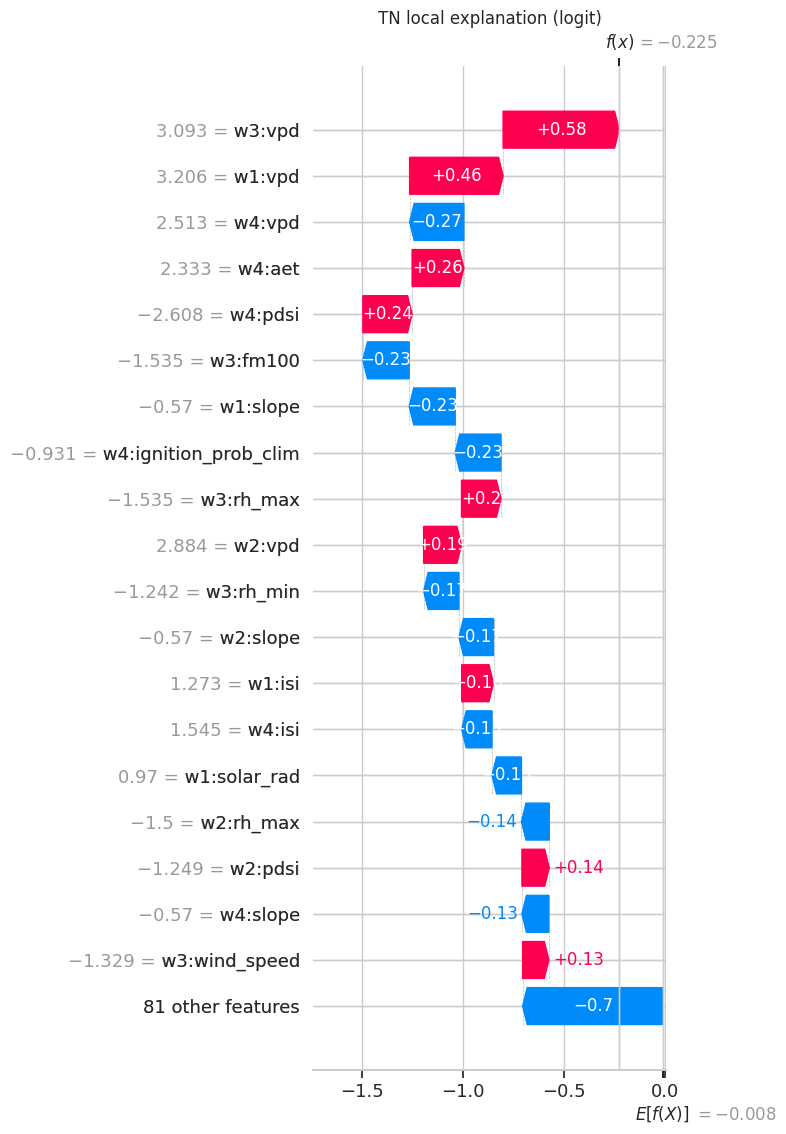

In [25]:
# -------------------------
# Local explanations: TP / FP / FN / TN
# -------------------------
def _token_table(sample_flat_shap, sample_flat_x, top_k=12):
    token_df = pd.DataFrame({
        "token": flat_feature_names,
        "shap_value": sample_flat_shap.astype(float),
        "feature_value": sample_flat_x.astype(float),
    })
    token_df["window"] = token_df["token"].str.split(":", n=1).str[0]
    token_df["feature"] = token_df["token"].str.split(":", n=1).str[1]
    pos = token_df.sort_values("shap_value", ascending=False).head(top_k).reset_index(drop=True)
    neg = token_df.sort_values("shap_value", ascending=True).head(top_k).reset_index(drop=True)
    return pos, neg

cats = {
    "TP": (pred_df["y_true"] == 1) & (pred_df["pred_0_5"] == 1),
    "FP": (pred_df["y_true"] == 0) & (pred_df["pred_0_5"] == 1),
    "FN": (pred_df["y_true"] == 1) & (pred_df["pred_0_5"] == 0),
    "TN": (pred_df["y_true"] == 0) & (pred_df["pred_0_5"] == 0),
}

local_summary_rows = []
for cname, cmask in cats.items():
    cand = pred_df.loc[cmask]
    if cand.empty:
        print(f"{cname}: not available in explained subset")
        continue

    ridx = int(cand.iloc[0]["sample_idx"])
    row_meta = pred_df.iloc[ridx]
    print("\n", "=" * 12, cname, "=" * 12)
    print({
        "target_date": row_meta.get("target_date", None),
        "row": int(row_meta.get("row", -1)),
        "col": int(row_meta.get("col", -1)),
        "y_true": int(row_meta["y_true"]),
        "logit": float(row_meta["logit"]),
        "prob": float(row_meta["prob"]),
        "pred_0_5": int(row_meta["pred_0_5"]),
    })

    sf = flat_shap[ridx]
    sx = flat_x[ridx]
    pos_df, neg_df = _token_table(sf, sx, top_k=12)

    print("Top positive contributors:")
    display(pos_df[["window", "feature", "shap_value", "feature_value"]])
    print("Top negative contributors:")
    display(neg_df[["window", "feature", "shap_value", "feature_value"]])

    pos_df.to_csv(explain_dir / f"shap_local_{cname.lower()}_top_positive.csv", index=False)
    neg_df.to_csv(explain_dir / f"shap_local_{cname.lower()}_top_negative.csv", index=False)

    # Optional waterfall
    try:
        exp = shap.Explanation(
            values=sf,
            base_values=bg_logit_mean,
            data=sx,
            feature_names=flat_feature_names,
        )
        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(exp, max_display=20, show=False)
        plt.title(f"{cname} local explanation (logit)")
        plt.tight_layout()
        plt.savefig(explain_dir / f"shap_local_{cname.lower()}_waterfall.png", dpi=180)
        plt.show()
    except Exception as e:
        print(f"Waterfall plot skipped for {cname}: {e}")

    local_summary_rows.append({"category": cname, "sample_idx": ridx})

pd.DataFrame(local_summary_rows).to_csv(explain_dir / "shap_local_samples_used.csv", index=False)
pred_df.to_csv(explain_dir / "shap_prediction_subset.csv", index=False)


### Interpretation Notes

- **Positive SHAP (logit space)** pushes prediction toward higher wildfire risk.
- **Negative SHAP** pushes prediction toward lower wildfire risk.
- **Mean absolute SHAP** gives global importance magnitude (not direction).
- **Window importance** indicates which lag band (`w1..w4`) contributes most.
- **Local explanations** show why a specific cell-day was predicted risky/not risky.


In [26]:
# -------------------------
# SHAP sanity summary + metadata
# -------------------------
saved_files = sorted([str(p.name) for p in explain_dir.glob("*")])

metadata = {
    "explainer_name": explainer_name,
    "device": str(device),
    "split_used": explain_split_name,
    "background_size": int(x_background_np.shape[0]),
    "explain_size": int(x_explain_np.shape[0]),
    "shap_output_shape": list(shap_values_np.shape),
    "flat_feature_count": int(len(flat_feature_names)),
    "t_steps": int(T),
    "n_features": int(F),
    "n_saved_artifacts": int(len(saved_files)),
}

assert shap_values_np.shape == x_explain_np.shape
assert len(flat_feature_names) == T * F

import json as _json
(explain_dir / "shap_metadata.json").write_text(_json.dumps(metadata, indent=2), encoding="utf-8")

print("Explainer used:", metadata["explainer_name"])
print("Background size:", metadata["background_size"])
print("Explain size:", metadata["explain_size"])
print("SHAP output shape:", metadata["shap_output_shape"])
print("Saved artifacts:", metadata["n_saved_artifacts"])
print("Artifacts dir:", explain_dir.resolve())
display(pd.DataFrame({"artifact": saved_files}))


Explainer used: GradientExplainer
Background size: 64
Explain size: 128
SHAP output shape: [128, 4, 25]
Saved artifacts: 21
Artifacts dir: /kaggle/working/artifacts/shap


,artifact
0,shap_feature_bar.png
1,shap_feature_importance.csv
2,shap_local_fn_top_negative.csv
3,shap_local_fn_top_positive.csv
4,shap_local_fn_waterfall.png
5,shap_local_fp_top_negative.csv
6,shap_local_fp_top_positive.csv
7,shap_local_fp_waterfall.png
8,shap_local_samples_used.csv
9,shap_local_tn_top_negative.csv
